# Decarbonisation of a Small Island Using PyPSA.

In [33]:
import pypsa
import pandas as pd

In [34]:
# Step 01: Initialize the PYPSA Network
network_old = pypsa.Network()

In [35]:
# Step 02: Define the snapshot times or simulation for the time frame (24)
snapshots = pd.date_range("2024-01-01", periods=24, freq="h")
network_old.set_snapshots(snapshots)

In [36]:
# Add the main bus
network_old.add("Bus", "Main Bus")

In [37]:
# Add conventional generators (coal generator)
network_old.add(
    "Generator",
    "Coal Plant",
    bus="Main Bus",
    p_nom=200,
    marginal_cost=80,
    carrier="coal",
)

In [38]:
# Add conventional generators(gas generator)
network_old.add(
    "Generator", "Gas Plant", bus="Main Bus", p_nom=150, marginal_cost=70, carrier="gas"
)

In [39]:
# Step 05: Add baseline load/demand profile (hourly demand)
hourly_load = [
    180,
    170,
    165,
    160,
    160,
    165,
    170,
    180,
    190,
    200,
    210,
    220,
    230,
    240,
    245,
    250,
    245,
    240,
    230,
    220,
    210,
    200,
    190,
    185,
]

network_old.add("Load", "Baseline Load", bus="Main Bus", p_set=hourly_load)

In [40]:
# Step 06: Optimize the network (Linear OPtimal Power Flow)
network_old.optimize()

/tmp/ipykernel_39069/984675460.py:2: FutureWarning: The default value of `include_objective_constant` will change from True to False in version 2.0. Set `include_objective_constant` explicitly to suppress this warning. Using False improves LP numerical conditioning by not including the objective constant as a variable.
  network_old.optimize()
Index(['Main Bus'], dtype='str', name='name')
Index(['Coal Plant', 'Gas Plant'], dtype='str', name='name')
INFO:linopy.model: Solve problem using Highs solver
INFO:linopy.io: Writing time: 0.03s
INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 48 primals, 120 duals
Objective: 3.52e+05
Solver model: available
Solver message: Optimal

INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Generator-fix-p-lower, Generator-fix-p-upper were not assigned to the network.


Running HiGHS 1.14.0 (git hash: 7df0786): Copyright (c) 2026 under MIT licence terms
LP linopy-problem-gzunrjie has 120 rows; 48 cols; 144 nonzeros
Coefficient ranges:
  Matrix  [1e+00, 1e+00]
  Cost    [7e+01, 8e+01]
  Bound   [0e+00, 0e+00]
  RHS     [2e+02, 2e+02]
Presolving model
0 rows, 0 cols, 0 nonzeros 0s
0 rows, 0 cols, 0 nonzeros 0s
Presolve reductions: rows 0(-120); columns 0(-48); nonzeros 0(-144) - Reduced to empty
Performed postsolve
Solving the original LP from the solution after postsolve

Model name          : linopy-problem-gzunrjie
Model status        : Optimal
Objective value     :  3.5240000000e+05
P-D objective error :  0.0000000000e+00
HiGHS run time      :          0.00


('ok', 'optimal')

In [41]:
# Step 07: Output the total system cost
initial_system_cost = network_old.objective
print(f"Initial System Cost: {initial_system_cost} USD")

Initial System Cost: 352400.0 USD


#### This initial setup creates a baseline scenario that reflects traditional fossil-fuel dependency. In the next sections, we transition toward a diversified, sustainable energy system by incrementally introducing renewable energy and storage technologies, modeling their economic and operational impacts

## Transition to a renewable energy system

In [42]:
import pypsa
import pandas as pd

In [43]:
# Step 01: Setup for the renewable energy system
network_new = pypsa.Network()

In [44]:
# Step 02:  Define time frame for the simulation (time series of 24 hours and snaphshots hourly)
snapshots = pd.date_range("2024-01-01", periods=24, freq="h")
network_new.set_snapshots(snapshots)

In [45]:
# Step 03: Create a new bus in the network
network_new.add("Bus", "Main Bus")

In [46]:
network_new.buses

,v_nom,type,x,y,carrier,unit,location,v_mag_pu_set,v_mag_pu_min,v_mag_pu_max,control,generator,sub_network
name,,,,,,,,,,,,,
Main Bus,1.0,,0.0,0.0,AC,,,1.0,0.0,inf,PQ,,


In [47]:
# Step 04: Define solar and wind availability patterns
solar_availability = [
    0,
    0,
    0,
    0,
    0,
    0,
    0.1,
    0.2,
    0.4,
    0.6,
    0.8,
    0.9,
    1.0,
    0.9,
    0.8,
    0.6,
    0.4,
    0.2,
    0.1,
    0,
    0,
    0,
    0,
    0,
]

wind_availability = [
    0.6,
    0.7,
    0.8,
    0.6,
    0.5,
    0.4,
    0.6,
    0.7,
    0.8,
    0.7,
    0.6,
    0.5,
    0.4,
    0.5,
    0.6,
    0.7,
    0.8,
    0.7,
    0.6,
    0.5,
    0.4,
    0.5,
    0.6,
    0.7,
]

In [48]:
# Step 05: Add renewable generators and backup gas plant (Diesel/Gas, fixed capacity and high cost)

# BACK UP DIESEL/GAS PLANT
network_new.add(
    "Generator",
    "Gas Plant",
    bus="Main Bus",
    p_nom=150,
    marginal_cost=200,
    carrier="gas",
)

In [49]:
# Solar PV - extendable capacity, with capital cost
network_new.add(
    "Generator",
    "Solar PV",
    bus="Main Bus",
    p_nom_extendable=True,
    capital_cost=600,
    marginal_cost=0,
    p_max_pu=solar_availability,
    carrier="solar",
)

In [50]:
# Onshore Wind - fixed capacity, with capital cost
network_new.add(
    "Generator",
    "Onshore Wind",
    bus="Main Bus",
    p_nom=150,
    capital_cost=800,
    marginal_cost=0,
    p_max_pu=wind_availability,
    carrier="wind",
)

In [51]:
# Step 05: Add baseline load/demand profile (hourly demand)
hourly_load = [
    180,
    170,
    165,
    160,
    160,
    165,
    170,
    180,
    190,
    200,
    210,
    220,
    230,
    240,
    245,
    250,
    245,
    240,
    230,
    220,
    210,
    200,
    190,
    185,
]

network_new.add("Load", "Baseline Load", bus="Main Bus", p_set=hourly_load)

In [52]:
# Step 07: Optimize the network using investment + dispatch optimization
network_new.optimize()

/tmp/ipykernel_39069/544387732.py:2: FutureWarning: The default value of `include_objective_constant` will change from True to False in version 2.0. Set `include_objective_constant` explicitly to suppress this warning. Using False improves LP numerical conditioning by not including the objective constant as a variable.
  network_new.optimize()
Index(['Main Bus'], dtype='str', name='name')
Index(['Gas Plant', 'Solar PV', 'Onshore Wind'], dtype='str', name='name')
INFO:linopy.model: Solve problem using Highs solver
INFO:linopy.io: Writing time: 0.04s
INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 73 primals, 169 duals
Objective: 4.05e+05
Solver model: available
Solver message: Optimal

INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Generator-fix-p-lower, Generator-fix-p-upper, Generator-ext-p-lower, Generator-ext-p-upper were not assigned to the network.


Running HiGHS 1.14.0 (git hash: 7df0786): Copyright (c) 2026 under MIT licence terms
LP linopy-problem-f_uzjf1_ has 169 rows; 73 cols; 230 nonzeros
Coefficient ranges:
  Matrix  [1e-01, 1e+00]
  Cost    [2e+02, 6e+02]
  Bound   [0e+00, 0e+00]
  RHS     [6e+01, 2e+02]
Presolving model
26 rows, 40 cols, 65 nonzeros 0s
Dependent equations search running on 10 equations with time limit of 1000.00s
Dependent equations search removed 0 rows and 0 nonzeros in 0.00s (limit = 1000.00s)
23 rows, 34 cols, 56 nonzeros 0s
Presolve reductions: rows 23(-146); columns 34(-39); nonzeros 56(-174) 
Solving the presolved LP
Using dual simplex solver
  Iteration        Objective     Infeasibilities num(sum)
          0     0.0000000000e+00 Ph1: 0(0) 0.0s
         22     4.0500000000e+05 Pr: 0(0) 0.0s

Performed postsolve
Solving the original LP from the solution after postsolve

Model name          : linopy-problem-f_uzjf1_
Model status        : Optimal
Simplex   iterations: 22
Objective value     :  4.050

('ok', 'optimal')

In [53]:
# Step 08: Print the total system cost and optimal solar capacity
print(f"Total System Cost (OPEX + CAPEX): {network_new.objective:.2f}")

Total System Cost (OPEX + CAPEX): 405000.00


In [54]:
print(
    f"Optimized Solar Capacity: {network_new.generators.at['Solar PV', 'p_nom_opt']:.2f} MW"
)

Optimized Solar Capacity: 183.33 MW


In [55]:
network_new.generators

,bus,control,type,p_nom,p_nom_mod,p_nom_extendable,p_nom_min,p_nom_max,p_nom_set,p_min_pu,...,min_up_time,min_down_time,up_time_before,down_time_before,ramp_limit_up,ramp_limit_down,ramp_limit_start_up,ramp_limit_shut_down,weight,p_nom_opt
name,,,,,,,,,,,,,,,,,,,,,
Gas Plant,Main Bus,Slack,,150.0,0.0,False,0.0,inf,NaN,0.0,...,0,0,1,0,NaN,NaN,NaN,NaN,1.0,150.000000
Solar PV,Main Bus,PQ,,0.0,0.0,True,0.0,inf,NaN,0.0,...,0,0,1,0,NaN,NaN,NaN,NaN,1.0,183.333333
Onshore Wind,Main Bus,PQ,,150.0,0.0,False,0.0,inf,NaN,0.0,...,0,0,1,0,NaN,NaN,NaN,NaN,1.0,150.000000


# Comparative Analysis of the Network between fossil fuel and renewable energy shares

In [56]:
import matplotlib.pyplot as plt

In [57]:
# Step 02: Define function to plot generation dispatch
def plot_generation_dispatch(network, title):
    gen_dispatch = network.generators_t.p
    gen_dispatch.plot(kind="bar", stacked=True, figsize=(15, 7))
    plt.title(title)
    plt.xlabel("Time (hours)")
    plt.ylabel("Generation (MW)")
    plt.legend(title="Generation Source")
    plt.show()

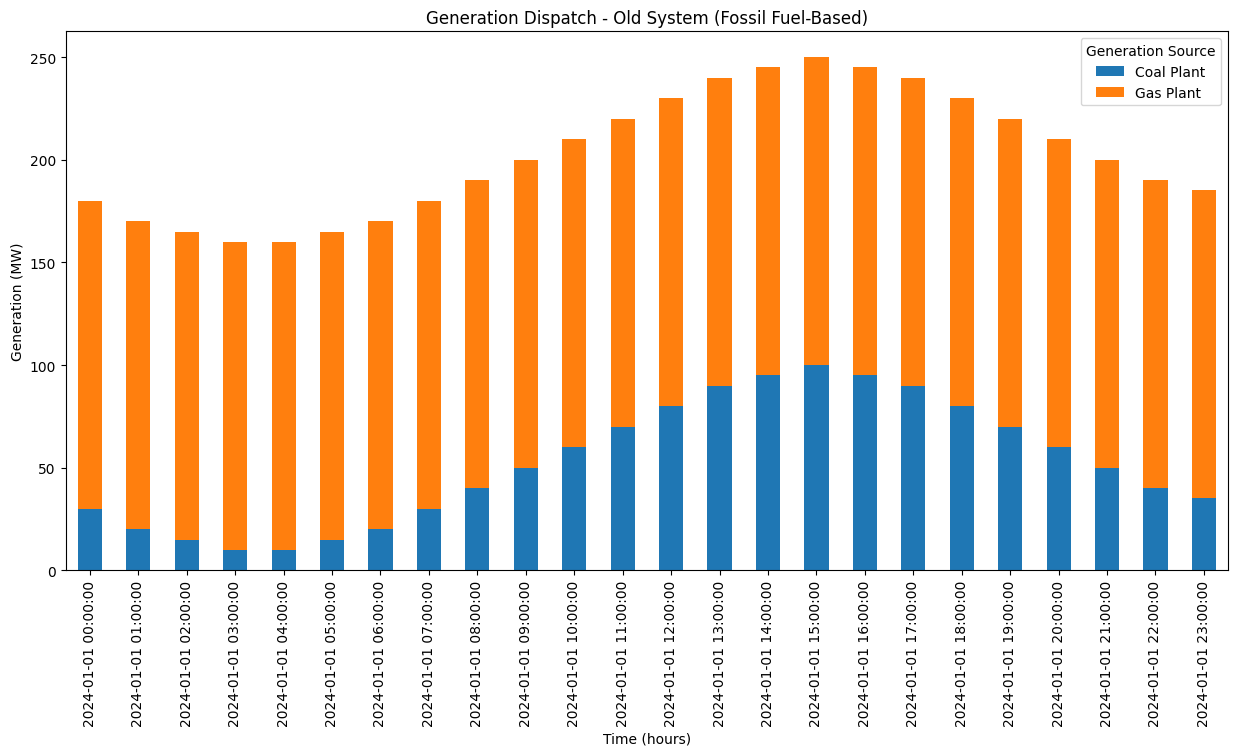

In [58]:
# Step 03: Plot generation dispatch for fossil based system
plot_generation_dispatch(
    network_old, "Generation Dispatch - Old System (Fossil Fuel-Based)"
)

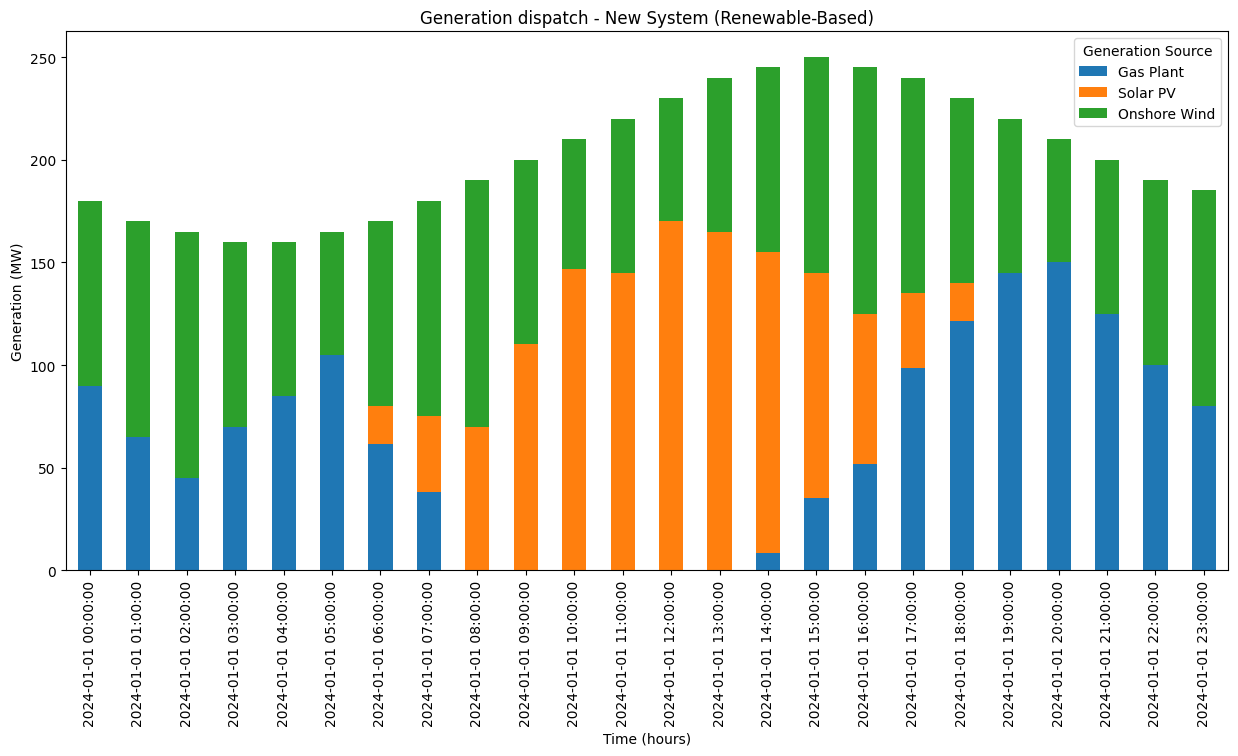

In [59]:
# Step 04: Plot generation dispatch for the renewable-based system
plot_generation_dispatch(
    network_new, "Generation dispatch - New System (Renewable-Based)"
)

# Economic impact: System Cost Comparison

In [60]:
# Step 01: Compare total system costs
print(f"Old Fossil System Cost (OPEX Only): " f"{network_old.objective:.2f}")

print(f"New Renewable System Cost (OPEX + CAPEX): " f"{network_new.objective:.2f}")

Old Fossil System Cost (OPEX Only): 352400.00
New Renewable System Cost (OPEX + CAPEX): 405000.00


In [61]:
# Step 02: Calculate OPEX-Only for the renewable system
renewable_opex = (
    (network_new.generators_t.p * network_new.generators.marginal_cost).sum().sum()
)

print(f"New Renewable System OPEX Only: " f"{renewable_opex}")

New Renewable System OPEX Only: 295000.0


In [62]:
"""In the absence of manual overrides, PyPSA assumes a default lifetime of 20 years
and a default discount rate of 7%.


# Set lifetime (25 years) individually for a generator
network.generators.at[’Solar PV’, ’lifetime’] = 25

# Set global discount rate (5%) for the entire network
network.global_parameters.update({"discount_rate": 0.05})
"""

'In the absence of manual overrides, PyPSA assumes a default lifetime of 20 years\nand a default discount rate of 7%.\n\n\n# Set lifetime (25 years) individually for a generator\nnetwork.generators.at[’Solar PV’, ’lifetime’] = 25\n\n# Set global discount rate (5%) for the entire network\nnetwork.global_parameters.update({"discount_rate": 0.05})\n'

# Environmental impact: Emissions comparison

In [ ]:
# Step 01
# Define emission factors
# (example values in tons of CO2 per MWh)

emission_factors = {
    "Coal Plant": 0.9,  # high emission for coal
    "Gas Plant": 0.4,  # moderate emissions for gas
    "Solar PV": 0,  # zero emissions for solar
    "Onshore Wind": 0,  # zero emissions for wind
}

In [64]:
# Step 02: Assign emission factors to generators
for gen_name, ef in emission_factors.items():
    if gen_name in network_old.generators.index:
        network_old.generators.loc[gen_name, "emission_factor"] = ef

    if gen_name in network_new.generators.index:
        network_new.generators.loc[gen_name, "emission_factor"] = ef

In [65]:
# Step 03: Define function to calculate total emissions
def calculate_total_emissions(network):
    emissions = 0
    for gen_name, gen_data in network.generators.iterrows():
        generation = network.generators_t.p[gen_name]
        emission_factor = gen_data["emission_factor"]
        gen_emissions = sum(generation * emission_factor)
        emissions += gen_emissions
    return emissions

In [66]:
# Step 04: Calculate emissions for both systems
old_emissions = calculate_total_emissions(network_old)
new_emissions = calculate_total_emissions(network_new)

In [67]:
print(f"Old System Emissions: {old_emissions} tons CO2")
print(f"New System Emissions: {new_emissions} tons C02")

Old System Emissions: 2569.5 tons CO2
New System Emissions: 590.0 tons C02
